- langchain - pre coded classes for implementing the basic react kind of agent
- langgraph - but if you want to design agent from scratch then use the langgprah.... low level control over the program

In [1]:
def hello_node(input: str):
    return {"message": f"Hello, {input}!"}

In [2]:
hello_node("areeb")

{'message': 'Hello, areeb!'}

In [3]:
from typing_extensions import TypedDict

In [4]:
class State(TypedDict):
    message: str

In [5]:
state: State = {"message": "hello areeb"}
state

{'message': 'hello areeb'}

In [6]:
def hello_node(state: State):
    return {"message": f"Hello, {state['message']}!"}

In [7]:
from langgraph.graph import StateGraph, START, END

In [12]:
builder = StateGraph(State)

In [13]:
builder.add_node("first_hello_node", hello_node)

In [14]:
builder.add_edge(START, "first_hello_node")

In [15]:
builder.add_edge("first_hello_node", END)

In [16]:
graph = builder.compile()

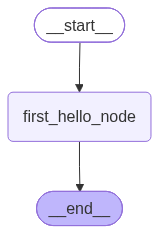

In [18]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
graph.invoke({"message": "from INDIA"})

{'message': 'Hello, from INDIA!'}

In [21]:
result = graph.invoke({"message": "from INDIA"})

In [22]:
result["message"]

'Hello, from INDIA!'

In [60]:
class Areeb(TypedDict):
    text: str

In [61]:
def function1(state: Areeb):
    print(f"state from first function : {state}")
    return {"text": state["text"] + " from first function"}

In [70]:
def function2(state: Areeb):
    print(f"state from second function : {state}")
    return {"text": state["text"] + " areeb from second function"}

In [71]:
workflow = StateGraph(Areeb)

In [72]:
workflow.add_node("func1", function1)
workflow.add_node("func2", function2)

In [73]:
workflow.add_edge(START, "func1")
workflow.add_edge("func1", "func2")
workflow.add_edge("func2", END)

In [74]:
app = workflow.compile()

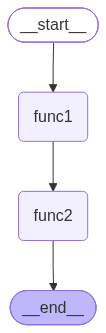

In [75]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [76]:
result = app.invoke({"text": "hi, this is Areeb"})

state from first function : {'text': 'hi, this is Areeb'}
state from second function : {'text': 'hi, this is Areeb from first function'}


In [77]:
result

{'text': 'hi, this is Areeb from first function areeb from second function'}

In [78]:
result["text"]

'hi, this is Areeb from first function areeb from second function'